# 02 EDA Additional

## 1. Data

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------
ROOT = Path.cwd().resolve().parent

PROCESSED_PATH = ROOT / "data" / "processed" / "yrbs_cycle3_substance_diet_processed_only.csv"

FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

# ------------------------------------------------------------
# Load processed-only data
# ------------------------------------------------------------
analysis = pd.read_csv(PROCESSED_PATH)

required_cols = [
    "sad_binary",
    "sad_group",
    "smoker_binary",
    "alcohol_binary",
    "marijuana_binary",
    "substance_risk_count",
    "fruit_daily_binary",
    "green_salad_daily_binary",
    "other_vegetable_daily_binary",
    "healthy_diet_count"
]

missing_cols = [col for col in required_cols if col not in analysis.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}. Please rerun 01_DataCheck.ipynb first.")

for col in required_cols:
    if col != "sad_group":
        analysis[col] = analysis[col].astype(int)

print("Rows valid for SadOrHopeless, substance-risk indicators, and healthy-diet indicators:", len(analysis))

Rows valid for SadOrHopeless, substance-risk indicators, and healthy-diet indicators: 11519


## 2. Behavior Count Summary

In [2]:
profile_summary = (
    analysis
    .groupby(["sad_binary", "sad_group"], as_index=False)
    .agg(
        n=("sad_binary", "count"),
        mean_substance_risk_count=("substance_risk_count", "mean"),
        mean_healthy_diet_count=("healthy_diet_count", "mean"),
        pct_2plus_substance_risks=("substance_risk_count", lambda x: (x >= 2).mean() * 100),
        pct_2plus_healthy_diet_behaviors=("healthy_diet_count", lambda x: (x >= 2).mean() * 100)
    )
    .sort_values("sad_binary", ascending=False)
    .reset_index(drop=True)
)

profile_summary.to_csv(
    TAB_DIR / "02_substance_diet_behavior_count_summary_by_sad_group.csv",
    index=False
)

display(profile_summary)

,sad_binary,sad_group,n,mean_substance_risk_count,mean_healthy_diet_count,pct_2plus_substance_risks,pct_2plus_healthy_diet_behaviors
0,1,Sad/Hopeless: Yes,3325,1.1059,0.6081,33.5338,17.4436
1,0,Sad/Hopeless: No,8194,0.7275,0.5903,20.4540,16.0483


#### **Interpretation**

The Sad/Hopeless: Yes group had a higher average number of substance-related risk behaviors than the Sad/Hopeless: No group. The healthy diet count was much more similar between the two groups.

This suggests that the stronger visible difference is mainly in the substance-related risk behavior domain, while healthy diet behaviors do not show the same clear separation.

## 3. Create Behavior Combination Variables

In [3]:
# ------------------------------------------------------------
# Helper functions for behavior combinations
# ------------------------------------------------------------
def create_combination_label(row, indicator_map):
    present = [label for col, label in indicator_map if row[col] == 1]

    if len(present) == 0:
        return "None"
    if len(present) == 3:
        return "All three"
    if len(present) == 1:
        return f"{present[0]} only"
    return " + ".join(present)


def build_combination_table(data, combination_col, output_name):
    group_order = ["Sad/Hopeless: No", "Sad/Hopeless: Yes"]

    counts = pd.crosstab(
        data[combination_col],
        data["sad_group"]
    ).reindex(columns=group_order, fill_value=0)

    props = pd.crosstab(
        data[combination_col],
        data["sad_group"],
        normalize="columns"
    ).reindex(columns=group_order, fill_value=0) * 100

    table = pd.DataFrame({
        "behavior_combination": counts.index,
        "no_count": counts["Sad/Hopeless: No"].values,
        "yes_count": counts["Sad/Hopeless: Yes"].values,
        "no_percent": props["Sad/Hopeless: No"].values,
        "yes_percent": props["Sad/Hopeless: Yes"].values
    })

    table.to_csv(TAB_DIR / output_name, index=False)
    return table

# Substance-related risk behavior combinations
substance_map = [
    ("smoker_binary", "Cigarette"),
    ("alcohol_binary", "Alcohol"),
    ("marijuana_binary", "Marijuana")
]

analysis["substance_behavior_combination"] = analysis.apply(
    lambda row: create_combination_label(row, substance_map),
    axis=1
)

substance_combination_table = build_combination_table(
    analysis,
    "substance_behavior_combination",
    "02_substance_behavior_combination_table.csv"
)

# Healthy diet behavior combinations
healthy_diet_map = [
    ("fruit_daily_binary", "Fruit"),
    ("green_salad_daily_binary", "Salad"),
    ("other_vegetable_daily_binary", "Vegetables")
]

analysis["healthy_diet_combination"] = analysis.apply(
    lambda row: create_combination_label(row, healthy_diet_map),
    axis=1
)

healthy_diet_combination_table = build_combination_table(
    analysis,
    "healthy_diet_combination",
    "02_healthy_diet_combination_table.csv"
)

print("Substance-related risk behavior combinations:")
display(substance_combination_table.sort_values("yes_percent", ascending=False))

print("Healthy diet behavior combinations:")
display(healthy_diet_combination_table.sort_values("yes_percent", ascending=False))

Substance-related risk behavior combinations:


,behavior_combination,no_count,yes_count,no_percent,yes_percent
7,None,4594,1298,56.0654,39.0376
1,Alcohol only,1659,775,20.2465,23.3083
2,All three,685,535,8.3598,16.0902
3,Cigarette + Alcohol,445,292,5.4308,8.7820
0,Alcohol + Marijuana,487,249,5.9434,7.4887
6,Marijuana only,139,73,1.6964,2.1955
5,Cigarette only,126,64,1.5377,1.9248
4,Cigarette + Marijuana,59,39,0.7200,1.1729


Healthy diet behavior combinations:


,behavior_combination,no_count,yes_count,no_percent,yes_percent
4,None,5047,2077,61.5938,62.4662
3,Fruit only,1107,395,13.5099,11.8797
2,Fruit + Vegetables,632,235,7.7130,7.0677
7,Vegetables only,581,201,7.0906,6.0451
0,All three,375,194,4.5765,5.8346
1,Fruit + Salad,221,112,2.6971,3.3684
6,Salad only,144,72,1.7574,2.1654
5,Salad + Vegetables,87,39,1.0618,1.1729


## 4. Visualization 1: UpSet-style Combination Plot for Substance-related Risk Behaviors

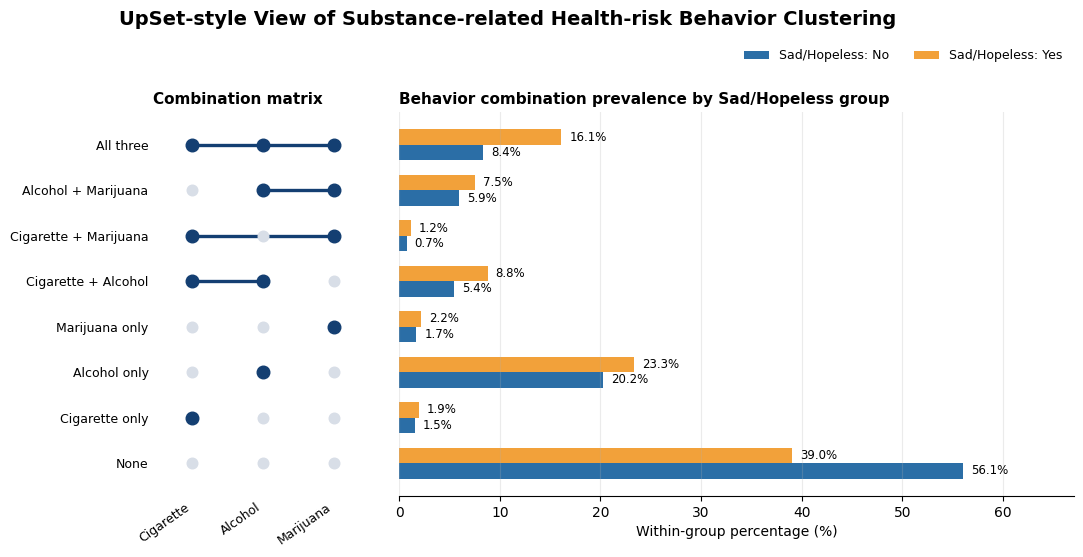

In [4]:
# ------------------------------------------------------------
# Helper function: UpSet-style combination plot
# ------------------------------------------------------------
def plot_upset_style_combination(
    combination_table,
    plot_order,
    behavior_cols,
    title,
    bar_title,
    output_filename,
    xlim_padding=11
):
    plot_df = (
        combination_table
        .set_index("behavior_combination")
        .reindex(plot_order)
        .fillna(0)
        .reset_index()
    )

    def combination_members(label):
        if label == "None":
            return []
        if label == "All three":
            return behavior_cols
        return [part.replace(" only", "") for part in label.split(" + ")]

    color_no = "#2b6ea6"
    color_yes = "#f2a13a"
    gray = "#d8dee7"
    dark = "#143f72"

    fig = plt.figure(figsize=(11.8, 6.0))

    gs = fig.add_gridspec(
        1,
        2,
        width_ratios=[1.25, 3.85],
        wspace=0.06
    )

    ax_matrix = fig.add_subplot(gs[0, 0])
    ax_bar = fig.add_subplot(gs[0, 1], sharey=ax_matrix)

    y = np.arange(len(plot_df))
    bar_h = 0.34

    # ------------------------------------------------------------
    # Matrix panel
    # ------------------------------------------------------------
    for i, label in enumerate(plot_df["behavior_combination"]):
        members = combination_members(label)
        xs_present = []

        for j, behavior in enumerate(behavior_cols):
            is_present = behavior in members

            ax_matrix.scatter(
                j,
                i,
                s=82 if is_present else 58,
                color=dark if is_present else gray,
                zorder=3
            )

            if is_present:
                xs_present.append(j)

        if len(xs_present) >= 2:
            ax_matrix.plot(
                [min(xs_present), max(xs_present)],
                [i, i],
                color=dark,
                linewidth=2.4,
                zorder=2
            )

    ax_matrix.set_xticks(range(len(behavior_cols)))
    ax_matrix.set_xticklabels(
        behavior_cols,
        rotation=35,
        ha="right",
        fontsize=9
    )

    ax_matrix.set_yticks(y)
    ax_matrix.set_yticklabels(plot_df["behavior_combination"], fontsize=9)

    ax_matrix.invert_yaxis()
    ax_matrix.set_xlim(-0.55, len(behavior_cols) - 0.45)
    ax_matrix.set_title(
        "Combination matrix",
        loc="left",
        fontsize=11,
        fontweight="bold"
    )

    ax_matrix.tick_params(axis="y", length=0)
    ax_matrix.tick_params(axis="x", length=0)

    for spine in ax_matrix.spines.values():
        spine.set_visible(False)

    # ------------------------------------------------------------
    # Paired horizontal bar panel
    # ------------------------------------------------------------
    ax_bar.barh(
        y + bar_h / 2,
        plot_df["no_percent"],
        height=bar_h,
        color=color_no,
        label="Sad/Hopeless: No"
    )

    ax_bar.barh(
        y - bar_h / 2,
        plot_df["yes_percent"],
        height=bar_h,
        color=color_yes,
        label="Sad/Hopeless: Yes"
    )

    # Show labels for all non-zero percentages
    for i, row in plot_df.iterrows():
        no_val = row["no_percent"]
        yes_val = row["yes_percent"]

        if no_val > 0:
            ax_bar.text(
                no_val + 0.8,
                i + bar_h / 2,
                f"{no_val:.1f}%",
                va="center",
                fontsize=8.5
            )

        if yes_val > 0:
            ax_bar.text(
                yes_val + 0.8,
                i - bar_h / 2,
                f"{yes_val:.1f}%",
                va="center",
                fontsize=8.5
            )

    ax_bar.set_xlabel("Within-group percentage (%)", fontsize=10)

    ax_bar.set_title(
        bar_title,
        loc="left",
        fontsize=11,
        fontweight="bold"
    )

    xmax = max(plot_df["no_percent"].max(), plot_df["yes_percent"].max())
    ax_bar.set_xlim(0, xmax + xlim_padding)

    ax_bar.grid(axis="x", alpha=0.25)
    ax_bar.tick_params(axis="y", left=False, labelleft=False)

    ax_bar.legend(
        loc="lower right",
        bbox_to_anchor=(1.0, 1.10),
        ncol=2,
        frameon=False,
        fontsize=9
    )

    for spine in ["top", "right", "left"]:
        ax_bar.spines[spine].set_visible(False)

    fig.suptitle(
        title,
        fontsize=14,
        fontweight="bold",
        y=0.97
    )

    fig.subplots_adjust(
        left=0.20,
        right=0.98,
        bottom=0.16,
        top=0.80,
        wspace=0.06
    )

    fig.savefig(
        FIG_DIR / output_filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# ------------------------------------------------------------
# Substance-related risk behavior UpSet-style plot
# ------------------------------------------------------------
substance_plot_order = [
    "All three",
    "Alcohol + Marijuana",
    "Cigarette + Marijuana",
    "Cigarette + Alcohol",
    "Marijuana only",
    "Alcohol only",
    "Cigarette only",
    "None"
]

plot_upset_style_combination(
    combination_table=substance_combination_table,
    plot_order=substance_plot_order,
    behavior_cols=["Cigarette", "Alcohol", "Marijuana"],
    title="UpSet-style View of Substance-related Health-risk Behavior Clustering",
    bar_title="Behavior combination prevalence by Sad/Hopeless group",
    output_filename="02_upset_style_substance_risk_behavior_combinations.png"
)

#### **Interpretation**

This UpSet-style plot shows which substance-related risk behaviors appear together within each Sad/Hopeless group.

The **Sad/Hopeless: Yes** group had a lower percentage of students with **None** of the three substance-related risk behaviors and a higher percentage of students reporting **All three** behaviors. This suggests stronger clustering of substance-related risk behaviors among students who felt sad or hopeless.

This result is exploratory and should be interpreted as an association, not causation.

## 5. Visualization 2: UpSet-style Combination Plot for Healthy Diet Behaviors

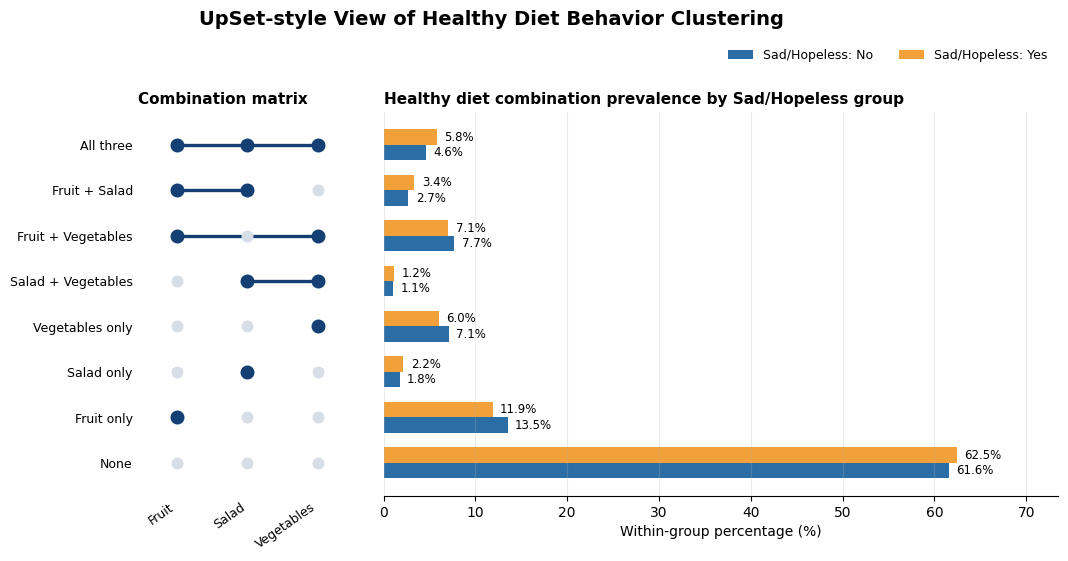

In [5]:
# ------------------------------------------------------------
# Healthy diet behavior UpSet-style plot
# ------------------------------------------------------------
healthy_diet_plot_order = [
    "All three",
    "Fruit + Salad",
    "Fruit + Vegetables",
    "Salad + Vegetables",
    "Vegetables only",
    "Salad only",
    "Fruit only",
    "None"
]

plot_upset_style_combination(
    combination_table=healthy_diet_combination_table,
    plot_order=healthy_diet_plot_order,
    behavior_cols=["Fruit", "Salad", "Vegetables"],
    title="UpSet-style View of Healthy Diet Behavior Clustering",
    bar_title="Healthy diet combination prevalence by Sad/Hopeless group",
    output_filename="02_upset_style_healthy_diet_behavior_combinations.png"
)

#### **Interpretation**

In this plot, **Salad** refers to daily green salad eating, and **Vegetables** refers to daily other vegetable eating.

This UpSet-style plot examines whether healthy diet behaviors cluster differently across Sad/Hopeless groups.

Compared with the substance-related risk behavior plot, the healthy diet combinations show a much weaker separation between the two groups. The percentages for many healthy diet combinations are relatively similar between the Sad/Hopeless: Yes and Sad/Hopeless: No groups.

This suggests that the clearer clustering pattern in this additional EDA appears in substance-related risk behaviors, while healthy diet behaviors show less obvious group separation.

## 6. Summary Profile: Sad/Hopeless Percentage by Behavior Count Level

,count_level,n,sad_count,sad_percent,domain
0,0,5892,1298,22.0000,Substance-risk count
1,1,2836,912,32.2000,Substance-risk count
2,2,1571,580,36.9000,Substance-risk count
3,3,1220,535,43.9000,Substance-risk count
4,0,7124,2077,29.2000,Healthy-diet count
5,1,2500,668,26.7000,Healthy-diet count
6,2,1326,386,29.1000,Healthy-diet count
7,3,569,194,34.1000,Healthy-diet count


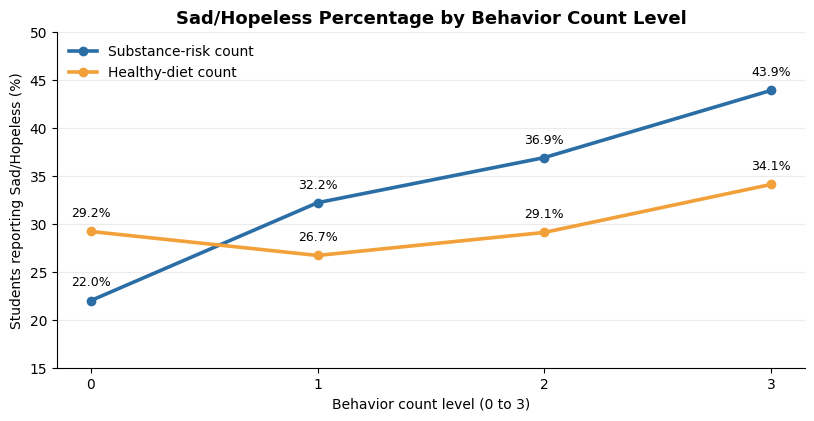

In [6]:
# ------------------------------------------------------------
# Sad/Hopeless percentage by behavior count level
# ------------------------------------------------------------

def build_sad_percent_by_count(data, count_col, domain_label):
    count_levels = [0, 1, 2, 3]

    table = (
        data
        .groupby(count_col)
        .agg(
            n=("sad_binary", "count"),
            sad_count=("sad_binary", "sum"),
            sad_percent=("sad_binary", lambda x: x.mean() * 100)
        )
        .reindex(count_levels)
        .reset_index()
        .rename(columns={count_col: "count_level"})
    )

    table["domain"] = domain_label
    table["sad_percent"] = table["sad_percent"].round(1)

    return table


substance_count_profile = build_sad_percent_by_count(
    analysis,
    "substance_risk_count",
    "Substance-risk count"
)

healthy_diet_count_profile = build_sad_percent_by_count(
    analysis,
    "healthy_diet_count",
    "Healthy-diet count"
)

count_profile = pd.concat(
    [substance_count_profile, healthy_diet_count_profile],
    ignore_index=True
)

count_profile.to_csv(
    TAB_DIR / "02_sad_hopeless_percent_by_behavior_count_level.csv",
    index=False
)

display(count_profile)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
color_substance = "#2b6ea6"
color_diet = "#f2a13a"

fig, ax = plt.subplots(figsize=(8.5, 4.6))

for domain, color in [
    ("Substance-risk count", color_substance),
    ("Healthy-diet count", color_diet)
]:
    plot_data = count_profile[count_profile["domain"] == domain].sort_values("count_level")

    ax.plot(
        plot_data["count_level"],
        plot_data["sad_percent"],
        marker="o",
        linewidth=2.6,
        markersize=6,
        color=color,
        label=domain
    )

    for _, row in plot_data.iterrows():
        ax.text(
            row["count_level"],
            row["sad_percent"] + 1.2,
            f"{row['sad_percent']:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

ax.set_title(
    "Sad/Hopeless Percentage by Behavior Count Level",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel("Behavior count level (0 to 3)", fontsize=10)
ax.set_ylabel("Students reporting Sad/Hopeless (%)", fontsize=10)
ax.set_xticks([0, 1, 2, 3])
ax.set_ylim(15, 50)
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False, loc="upper left")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.subplots_adjust(left=0.10, right=0.98, bottom=0.15, top=0.88)

fig.savefig(
    FIG_DIR / "02_sad_hopeless_percent_by_behavior_count_level.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


#### **Interpretation**

This summary profile compares the percentage of students reporting Sad/Hopeless across behavior count levels.

For **substance-related risk behaviors**, the Sad/Hopeless percentage increased steadily from count level 0 to count level 3. This suggests that students with more substance-related risk behaviors were more likely to report feeling sad or hopeless.

For **healthy diet behaviors**, the pattern was less consistent. The Sad/Hopeless percentage did not clearly decrease as the healthy diet count increased. This suggests that healthy diet behavior count did not show the same clear pattern as substance-related risk behavior count in this exploratory analysis.

The count levels are ordered categories, not time points, so this figure should be interpreted as a profile across behavior count levels rather than a time trend.


## 7. Additional EDA Takeaway

Overall, Sad/Hopeless status appears more visibly associated with substance-related risk behavior clustering than with healthy diet behavior clustering in this sample. Because the YRBS data are observational, this does not imply causation.